#Importing Required Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
uploaded = files.upload()

Saving ecommerce_customer_churn_dataset.csv to ecommerce_customer_churn_dataset.csv


In [ ]:
data = pd.read_csv("ecommerce_customer_churn_dataset.csv")

#Data Expolration


In [ ]:
data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  int64  
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

#Data cleaning

In [ ]:
data.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
numeric_columns = data.select_dtypes(include=np.number).columns

for col in numeric_columns:
    data[col] = data[col].fillna(data[col].mean())

#EDA

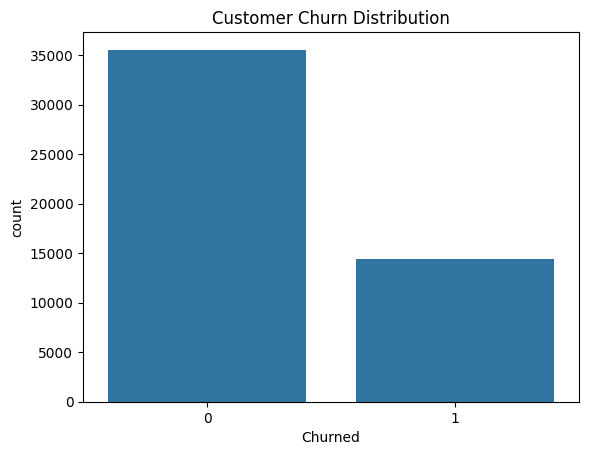

In [ ]:
sns.countplot(x='Churned', data=data)

plt.title('Customer Churn Distribution')

plt.show()

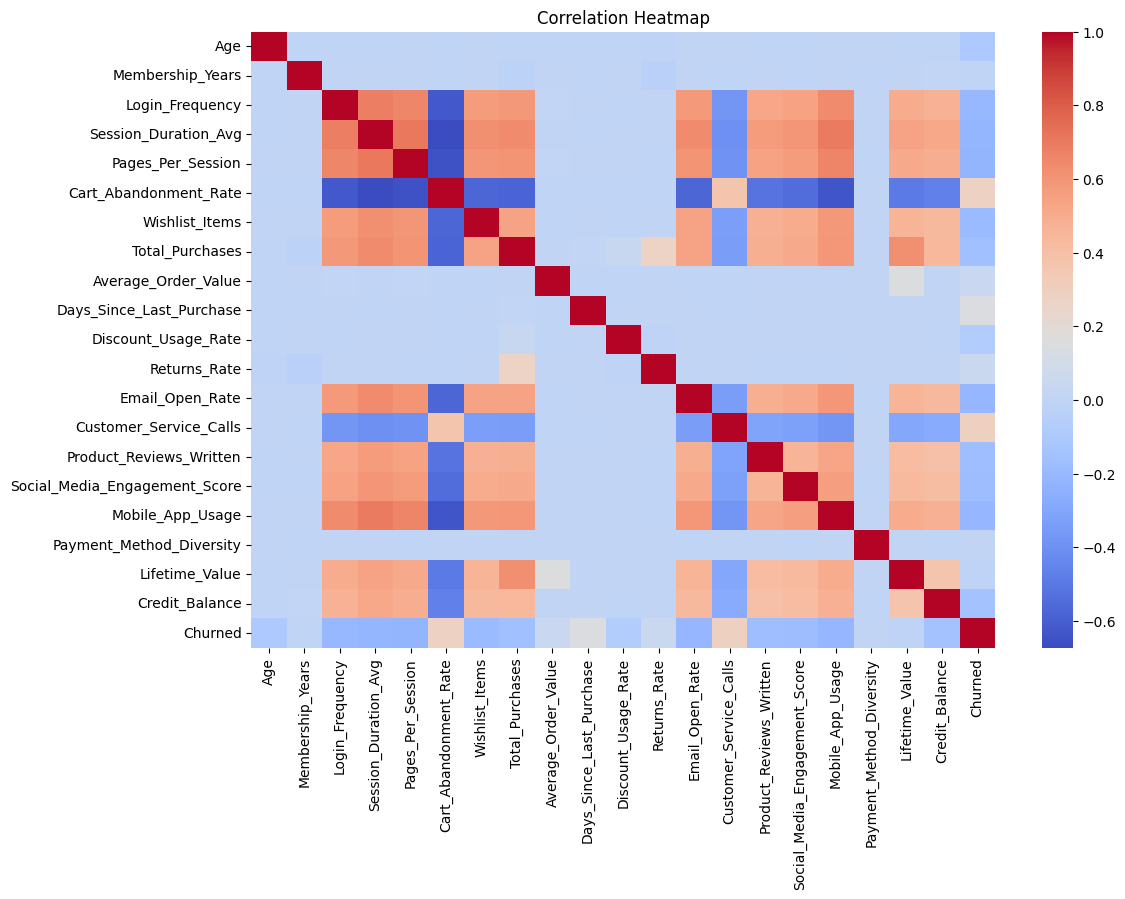

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

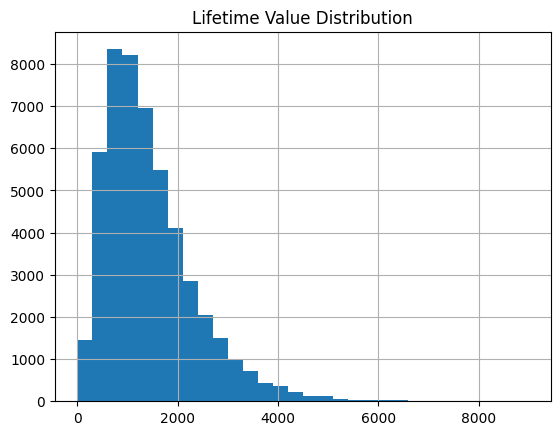

In [ ]:
data['Lifetime_Value'].hist(bins=30)

plt.title('Lifetime Value Distribution')

plt.show()

#Preprocessing

In [ ]:
y = data['Churned']
X = data.drop('Churned', axis=1)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Applying PCA (Dimension Reduction)

In [ ]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Shape Before PCA:", X_scaled.shape)
print("Shape After PCA:", X_pca.shape)

Shape Before PCA: (50000, 71)
Shape After PCA: (50000, 54)


In [ ]:
print(pca.explained_variance_ratio_)

[0.10257796 0.03434131 0.03083435 0.0302216  0.02978921 0.02951335
 0.02915232 0.02072058 0.01885418 0.01602038 0.01580062 0.01549714
 0.01520621 0.01515866 0.01514925 0.01512585 0.01485846 0.01470383
 0.01460223 0.01458545 0.0145204  0.01450428 0.0145003  0.01446945
 0.01444195 0.01442632 0.01442195 0.01439827 0.0143605  0.01435238
 0.01434998 0.01433025 0.01432661 0.01431921 0.01430618 0.01430183
 0.01429469 0.01428741 0.01427457 0.01426998 0.0142495  0.0142297
 0.01421275 0.01417146 0.01390039 0.01383568 0.01378146 0.01361659
 0.01295945 0.01215419 0.01081855 0.00891977 0.00830577 0.00772826]


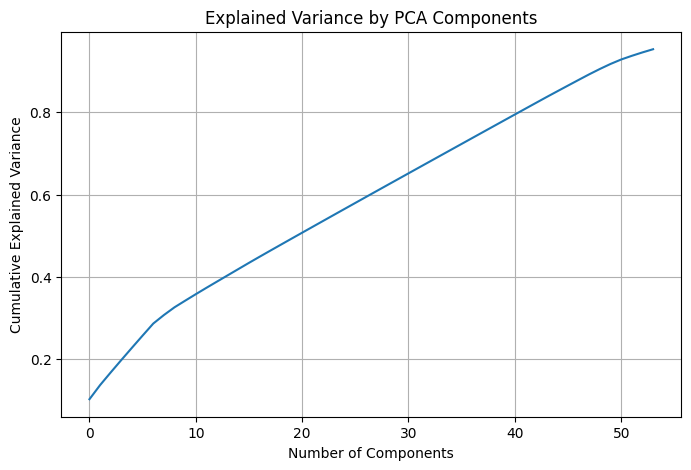

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

#Splitting the Dataset


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

#Models


In [ ]:
X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_before_model = LogisticRegression()
lr_before_model.fit(X_train_before, y_train_before)

lr_before_pred = lr_before_model.predict(X_test_before)

lr_before_accuracy = accuracy_score(y_test_before, lr_before_pred)

print("Logistic Regression Before PCA Accuracy:", lr_before_accuracy)

Logistic Regression Before PCA Accuracy: 0.7772


In [ ]:
rf_before_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_before_model.fit(X_train_before, y_train_before)

rf_before_pred = rf_before_model.predict(X_test_before)

rf_before_accuracy = accuracy_score(y_test_before, rf_before_pred)

print("Random Forest Before PCA Accuracy:", rf_before_accuracy)

Random Forest Before PCA Accuracy: 0.9129


In [ ]:
X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
lr_after_model = LogisticRegression(class_weight='balanced')
lr_after_model.fit(X_train_after, y_train_after)

lr_after_pred = lr_after_model.predict(X_test_after)

lr_after_accuracy = accuracy_score(y_test_after, lr_after_pred)

print("Logistic Regression After PCA Accuracy:", lr_after_accuracy)

Logistic Regression After PCA Accuracy: 0.6985


In [ ]:
rf_after_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_after_model.fit(X_train_after, y_train_after)

rf_after_pred = rf_after_model.predict(X_test_after)

rf_after_accuracy = accuracy_score(y_test_after, rf_after_pred)

print("Random Forest After PCA Accuracy:", rf_after_accuracy)

Random Forest After PCA Accuracy: 0.8164


In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Before PCA Accuracy': [
        lr_before_accuracy,
        rf_before_accuracy
    ],
    'After PCA Accuracy': [
        lr_after_accuracy,
        rf_after_accuracy
    ]
})

print(results)

                 Model  Before PCA Accuracy  After PCA Accuracy
0  Logistic Regression               0.7772              0.6985
1        Random Forest               0.9129              0.8164


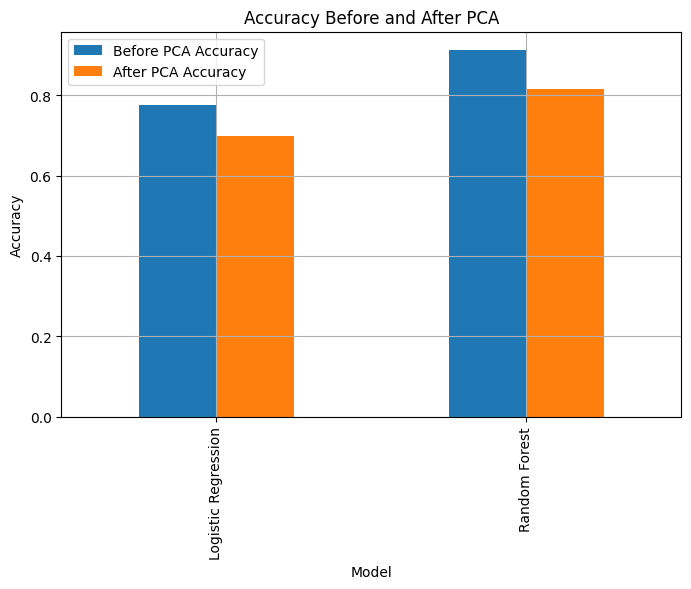

In [ ]:
results.plot(
    x='Model',
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Accuracy')
plt.title('Accuracy Before and After PCA')
plt.grid()
plt.show()

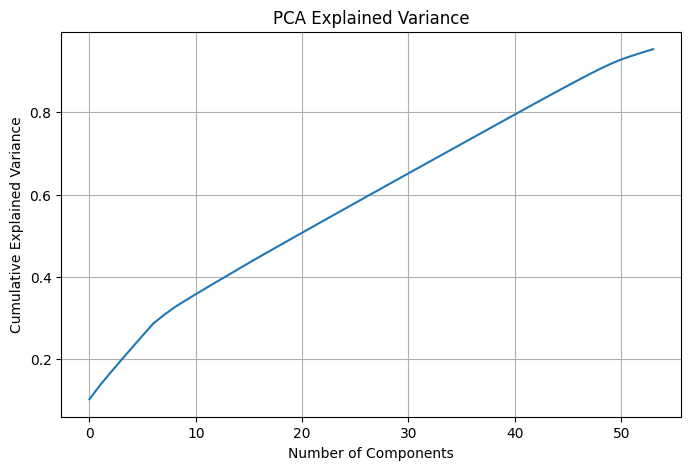

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

#Confusion Matrix for Best Model


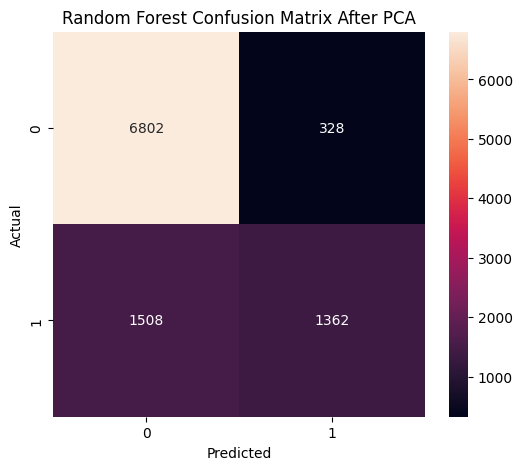

In [ ]:
print(classification_report(y_test_after, rf_after_pred))

              precision    recall  f1-score   support

           0       0.82      0.95      0.88      7130
           1       0.81      0.47      0.60      2870

    accuracy                           0.82     10000
   macro avg       0.81      0.71      0.74     10000
weighted avg       0.81      0.82      0.80     10000



In [ ]:
data['Churned'].value_counts()

,count
Churned,
0,35550
1,14450
